# Nghien cuu chuyen dich ky nang khi co AI

Notebook nay di theo dung flow nghien cuu:

1. **Khi co AI: tan suat su dung va cam nhan khi dung**.
2. **Mong muon tu dong hoa, kha nang tu dong hoa va kha nang kiem soat cua con nguoi**.
3. **Lo ngai khi dung AI**.
4. **Suy luan bang mo hinh hoi quy/uoc luong de xem nghe va nganh chuyen dich nhu the nao**.

Ban nay da bo sung cac kiem tra chat luong khoa hoc: do phu mau, missingness, clustered standard errors theo user/task, kiem tra da cong tuyen, loc ranking mau nho, va sensitivity analysis cho chi so chuyen dich.

Luu y: cac mo hinh trong notebook la mo hinh lien he thong ke/uoc luong kham pha, chua phai ket luan nhan qua.

## Setup

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

desires = pd.read_csv(ROOT / "domain_worker_desires.csv")
meta = pd.read_csv(ROOT / "domain_worker_metadata.csv")
expert = pd.read_csv(ROOT / "expert_rated_technological_capability.csv").drop_duplicates()
tasks = pd.read_csv(ROOT / "task_statement_with_metadata.csv")

usage = pd.read_csv(ROOT / "external_data" / "usage_from_anthropic.csv")
papers = pd.read_csv(ROOT / "external_data" / "paper_to_workflow_mapping_aggregated.csv")
companies = pd.read_csv(ROOT / "external_data" / "company_to_workflow_aggregation.csv")

print("Loaded:")
print("desires", desires.shape)
print("meta", meta.shape)
print("expert", expert.shape)
print("tasks", tasks.shape)

Loaded:
desires (5731, 31)
meta (1500, 26)
expert (2038, 11)
tasks (2131, 14)


In [2]:
def normalize_text(value):
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip(" .")


def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    std = series.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.mean(skipna=True)) / std


def clean_sector_name(path):
    return path.stem.replace("_", " ")


likert_map = {
    "Strongly disagree": 1,
    "Somewhat disagree": 2,
    "Neither agree nor disagree": 3,
    "Somewhat agree": 4,
    "Strongly agree": 5,
}

usage_freq_map = {"Never": 0, "Monthly": 1, "Weekly": 2, "Daily": 3}

llm_familiarity_map = {
    "No, I've never heard of them.": 0,
    "I have heard of them but don't know much about their functionalities.": 1,
    "I have some experience using them.": 2,
    "I use them regularly.": 3,
}

llm_work_use_map = {
    "No, I've never heard of them.": 0,
    "No, I have not used them for any work-related activities.": 0,
    "Yes, I have used them occasionally for specific tasks.": 1,
    "Yes, I use them every week in my work.": 2,
    "Yes, I use them every day in my work.": 3,
}


def build_sector_lookup():
    frames = []
    sector_dir = ROOT / "external_data" / "onet_data" / "onet_sector"
    for path in sorted(sector_dir.glob("*.csv")):
        frame = pd.read_csv(path)
        frame["sector"] = clean_sector_name(path)
        frames.append(frame)
    sector = pd.concat(frames, ignore_index=True)
    sector["occupation_norm"] = sector["Occupation"].map(normalize_text)
    return sector[["occupation_norm", "sector"]].drop_duplicates()


sector_lookup = build_sector_lookup()

# Cell 1. Khi có AI: tần suất sử dụng và cảm nhận khi dùng

Mục tiêu cell này: xem người lao động đã dùng AI/LLM thường xuyên đến đâu, dùng vào việc gì, và cảm nhận chung của họ về AI trong công việc.

In [3]:
ai_experience = meta.copy()
ai_experience["llm_familiarity_score"] = ai_experience["LLM Familiarity"].map(llm_familiarity_map)
ai_experience["llm_work_use_score"] = ai_experience["LLM Use in Work"].map(llm_work_use_map)

attitude_cols = [
    "AI Tedious Work Attitude",
    "AI Job Importance Attitude",
    "AI Daily Interest Attitude",
    "AI Suffering Attitude",
]
for col in attitude_cols:
    ai_experience[col + " Score"] = ai_experience[col].map(likert_map)

usage_type_cols = [c for c in ai_experience.columns if c.startswith("LLM Usage by Type -")]
for col in usage_type_cols:
    ai_experience[col + " Score"] = ai_experience[col].map(usage_freq_map)

ai_experience["ai_positive_feeling_score"] = ai_experience[
    [
        "AI Tedious Work Attitude Score",
        "AI Job Importance Attitude Score",
        "AI Daily Interest Attitude Score",
    ]
].mean(axis=1)
ai_experience["ai_suffering_concern_score"] = ai_experience["AI Suffering Attitude Score"]

print("### Mức độ quen thuộc với LLM")
display(ai_experience["LLM Familiarity"].value_counts().rename_axis("LLM Familiarity").reset_index(name="workers"))

print("### Tần suất dùng LLM trong công việc")
display(ai_experience["LLM Use in Work"].value_counts().rename_axis("LLM Use in Work").reset_index(name="workers"))

print("### Cảm nhận trung bình về AI")
feeling_summary = ai_experience[
    [
        "AI Tedious Work Attitude Score",
        "AI Job Importance Attitude Score",
        "AI Daily Interest Attitude Score",
        "AI Suffering Attitude Score",
        "ai_positive_feeling_score",
    ]
].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(3)
display(feeling_summary)

### Mức độ quen thuộc với LLM


,LLM Familiarity,workers
0,I use them regularly.,829
1,I have some experience using them.,551
2,I have heard of them but don't know much about their functionalities.,110
3,"No, I've never heard of them.",10


### Tần suất dùng LLM trong công việc


,LLM Use in Work,workers
0,"Yes, I use them every day in my work.",507
1,"Yes, I have used them occasionally for specific tasks.",414
2,"Yes, I use them every week in my work.",307
3,"No, I have not used them for any work-related activities.",246
4,"No, I've never heard of them.",26


### Cảm nhận trung bình về AI


,count,mean,std,min,50%,max
AI Tedious Work Attitude Score,1500.0,4.117,1.114,1.0,4.0,5.0
AI Job Importance Attitude Score,1500.0,3.261,1.272,1.0,3.0,5.0
AI Daily Interest Attitude Score,1500.0,3.920,1.246,1.0,4.0,5.0
AI Suffering Attitude Score,1500.0,2.723,1.325,1.0,3.0,5.0
ai_positive_feeling_score,1500.0,3.766,0.847,1.0,4.0,5.0


,usage_type,mean_frequency_score,daily_share,weekly_or_daily_share
0,Information Access,2.028,0.328,0.600
3,Communication,1.985,0.356,0.576
1,Edit,1.924,0.285,0.572
2,Idea Generation,1.843,0.281,0.533
4,Analysis,1.785,0.284,0.517
8,Data Processing,1.642,0.255,0.472
5,Decision,1.558,0.239,0.449
6,Coding,1.297,0.172,0.367
7,System Design,0.944,0.109,0.258


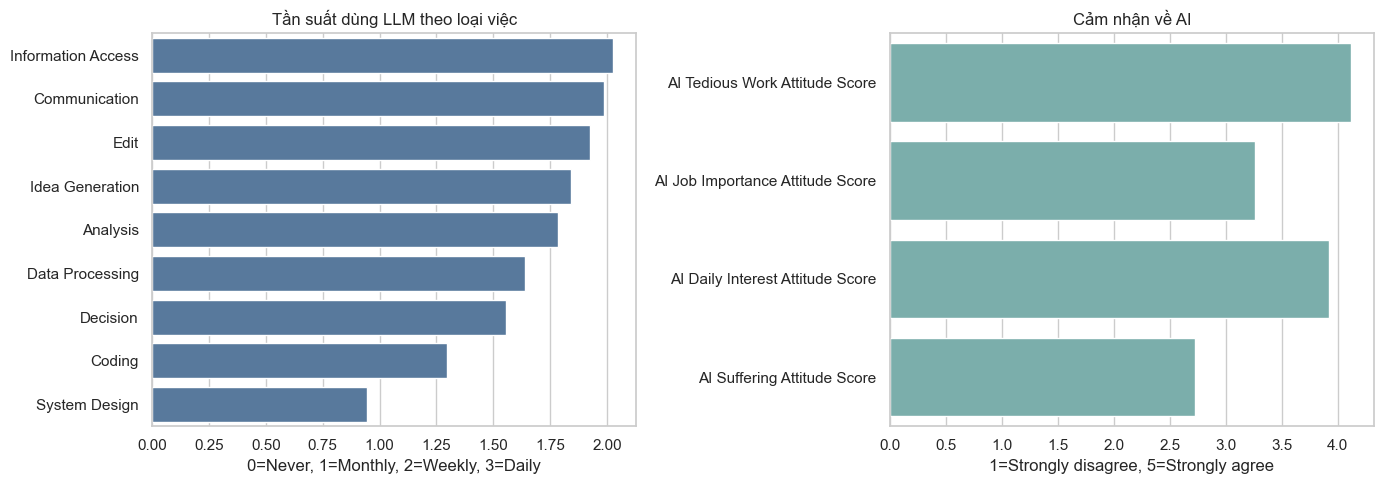

In [4]:
usage_by_type = []
for col in usage_type_cols:
    short_name = col.replace("LLM Usage by Type - ", "")
    usage_by_type.append(
        {
            "usage_type": short_name,
            "mean_frequency_score": ai_experience[col + " Score"].mean(),
            "daily_share": (ai_experience[col] == "Daily").mean(),
            "weekly_or_daily_share": ai_experience[col].isin(["Weekly", "Daily"]).mean(),
        }
    )
usage_by_type = pd.DataFrame(usage_by_type).sort_values("mean_frequency_score", ascending=False)
display(usage_by_type.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=usage_by_type, x="mean_frequency_score", y="usage_type", ax=axes[0], color="#4C78A8")
axes[0].set_title("Tần suất dùng LLM theo loại việc")
axes[0].set_xlabel("0=Never, 1=Monthly, 2=Weekly, 3=Daily")
axes[0].set_ylabel("")

feeling_means = feeling_summary.loc[
    [
        "AI Tedious Work Attitude Score",
        "AI Job Importance Attitude Score",
        "AI Daily Interest Attitude Score",
        "AI Suffering Attitude Score",
    ],
    "mean",
].reset_index()
feeling_means.columns = ["attitude", "mean_score"]
sns.barplot(data=feeling_means, x="mean_score", y="attitude", ax=axes[1], color="#72B7B2")
axes[1].set_title("Cảm nhận về AI")
axes[1].set_xlabel("1=Strongly disagree, 5=Strongly agree")
axes[1].set_ylabel("")
plt.tight_layout()

# Cell 2. Mong muốn tự động hóa, khả năng tự động hóa và khả năng kiểm soát

Cell này ghép 3 lớp:

- **Worker desire**: người lao động muốn AI làm thay/hỗ trợ đến đâu.
- **Expert capability**: chuyên gia đánh giá AI có khả năng tự động hóa task đến đâu.
- **Human control/agency**: task vẫn cần con người kiểm soát/ra quyết định đến đâu.

In [5]:
worker_task = desires.groupby("Task ID", as_index=False).agg(
    worker_raters=("User ID", "nunique"),
    automation_desire=("Automation Desire Rating", "mean"),
    core_skill=("Core Skill Rating", "mean"),
    job_security=("Job Security Rating", "mean"),
    enjoyment=("Enjoyment Rating", "mean"),
    worker_human_agency=("Human Agency Scale Rating", "mean"),
    worker_control_reason=("Reasons for Human Agency - Control", "mean"),
    worker_quality_oversight_reason=("Reasons for Human Agency - Quality Oversight", "mean"),
    worker_ethical_reason=("Reasons for Human Agency - Ethical", "mean"),
)

expert_task = expert.groupby("Task ID", as_index=False).agg(
    expert_raters=("User ID", "nunique"),
    ai_capability=("Automation Capacity Rating", "mean"),
    expert_human_agency=("Human Agency Scale Rating", "mean"),
    physical_requirement=("Physical Action Requirement", "mean"),
    uncertainty=("Involved Uncertainty", "mean"),
    domain_expertise=("Domain Expertise Requirement", "mean"),
    interpersonal=("Interpersonal Communication Requirement", "mean"),
)

task_base = tasks.copy()
task_base["task_norm"] = task_base["Task"].map(normalize_text)
task_base["occupation_norm"] = task_base["Occupation (O*NET-SOC Title)"].map(normalize_text)
task_base = task_base.merge(sector_lookup, on="occupation_norm", how="left")

task_ai = task_base.merge(worker_task, on="Task ID", how="left").merge(expert_task, on="Task ID", how="left")
task_ai["human_agency"] = task_ai[["worker_human_agency", "expert_human_agency"]].mean(axis=1)
task_ai["capability_desire_gap"] = task_ai["ai_capability"] - task_ai["automation_desire"]
task_ai["desire_capability_gap"] = task_ai["automation_desire"] - task_ai["ai_capability"]

display(task_ai[["automation_desire", "ai_capability", "human_agency", "capability_desire_gap"]].describe().round(3))

paired_tasks = task_ai.dropna(subset=["automation_desire", "ai_capability", "human_agency"]).copy()
print("Tasks with worker + expert + agency signal:", len(paired_tasks))

,automation_desire,ai_capability,human_agency,capability_desire_gap
count,844.000,846.000,846.000,844.000
mean,3.018,3.459,2.741,0.442
std,0.595,0.891,0.597,0.986
min,1.500,1.333,1.167,-2.333
25%,2.600,2.750,2.312,-0.216
50%,3.000,3.500,2.731,0.500
75%,3.429,4.000,3.167,1.114
max,5.000,5.000,4.375,3.000


Tasks with worker + expert + agency signal: 844


### Nơi AI có khả năng cao nhưng vẫn cần con người kiểm soát


,Task ID,Occupation (O*NET-SOC Title),Task,ai_capability,automation_desire,human_agency
45,15428,Quality Control Systems Managers,Analyze quality control test results and provide feedback and interpretation to production management or staff.,5.0,2.500000,2.500000
1583,9416,Medical Transcriptionists,"Return dictated reports in printed or electronic form for physician's review, signature, and corrections and for inclusion in patients' ...",5.0,3.000000,2.500000
1782,2587,Customer Service Representatives,Review insurance policy terms to determine whether a particular loss is covered by insurance.,5.0,2.857143,2.500000
1683,2489,"Bookkeeping, Accounting, and Auditing Clerks","Debit, credit, and total accounts on computer spreadsheets and databases, using specialized accounting software.",5.0,2.750000,2.437500
1588,9423,Medical Transcriptionists,"Set up and maintain medical files and databases, including records such as x-ray, lab, and procedure reports, medical histories, diagnos...",5.0,3.285714,2.428571
51,15423,Quality Control Systems Managers,"Document testing procedures, methodologies, or criteria.",5.0,2.833333,2.416667
1678,2493,"Bookkeeping, Accounting, and Auditing Clerks",Code documents according to company procedures.,5.0,3.000000,2.375000
93,993,Human Resources Managers,"Maintain records and compile statistical reports concerning personnel-related data such as hires, transfers, performance appraisals, and...",5.0,3.100000,2.300000
1632,11252,"Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products","Complete expense reports, sales reports, or other paperwork.",5.0,4.111111,2.250000
1679,2497,"Bookkeeping, Accounting, and Auditing Clerks","Perform financial calculations, such as amounts due, interest charges, balances, discounts, equity, and principal.",5.0,3.400000,2.250000


### Nơi worker muốn AI hỗ trợ mạnh hơn khả năng hiện tại


,Task ID,Occupation (O*NET-SOC Title),Task,automation_desire,ai_capability,desire_capability_gap
588,16212,Video Game Designers,"Create and manage documentation, production schedules, prototyping goals, and communication plans in collaboration with production staff.",3.666667,1.333333,2.333333
526,1317,Network and Computer Systems Administrators,Perform data backups and disaster recovery operations.,3.750000,1.500000,2.250000
130,18030,Regulatory Affairs Managers,"Maintain current knowledge of relevant regulations, including proposed and final rules.",3.714286,1.500000,2.214286
1945,784,Medical Secretaries and Administrative Assistants,"Perform various clerical or administrative functions, such as ordering and maintaining an inventory of supplies.",3.833333,1.666667,2.166667
1470,3975,Technical Writers,"Arrange for typing, duplication, and distribution of material.",4.000000,2.000000,2.000000
871,3589,Petroleum Engineers,"Evaluate findings to develop, design, or test equipment or processes.",4.000000,2.000000,2.000000
1402,22529,Producers and Directors,"Perform administrative duties, such as preparing operational reports, distributing rehearsal call sheets and script copies, and arrangin...",3.800000,2.000000,1.800000
1187,16964,Quality Control Analysts,"Write technical reports or documentation, such as deviation reports, testing protocols, and trend analyses.",3.750000,2.000000,1.750000
530,1319,Network and Computer Systems Administrators,"Plan, coordinate, and implement network security measures to protect data, software, and hardware.",3.714286,2.000000,1.714286
1631,11246,"Sales Representatives, Wholesale and Manufacturing, Technical and Scientific Products",Prepare sales presentations or proposals to explain product specifications or applications.,3.200000,1.500000,1.700000


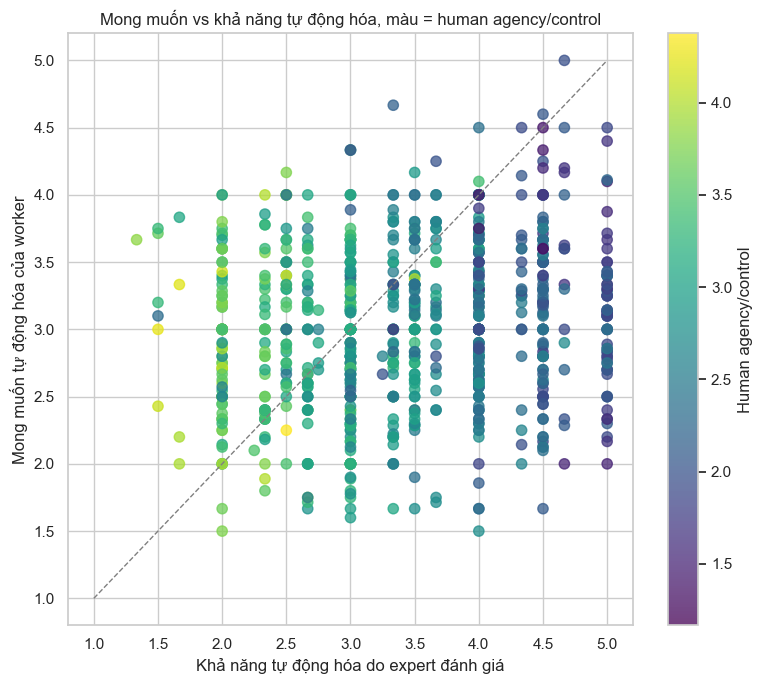

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    paired_tasks["ai_capability"],
    paired_tasks["automation_desire"],
    c=paired_tasks["human_agency"],
    cmap="viridis",
    s=55,
    alpha=0.75,
)
ax.plot([1, 5], [1, 5], linestyle="--", color="gray", linewidth=1)
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0.8, 5.2)
ax.set_xlabel("Khả năng tự động hóa do expert đánh giá")
ax.set_ylabel("Mong muốn tự động hóa của worker")
ax.set_title("Mong muốn vs khả năng tự động hóa, màu = human agency/control")
plt.colorbar(scatter, ax=ax, label="Human agency/control")
plt.tight_layout()

print("### Nơi AI có khả năng cao nhưng vẫn cần con người kiểm soát")
display(
    paired_tasks.sort_values(["ai_capability", "human_agency"], ascending=False)[
        ["Task ID", "Occupation (O*NET-SOC Title)", "Task", "ai_capability", "automation_desire", "human_agency"]
    ].head(15)
)

print("### Nơi worker muốn AI hỗ trợ mạnh hơn khả năng hiện tại")
display(
    paired_tasks.sort_values("desire_capability_gap", ascending=False)[
        ["Task ID", "Occupation (O*NET-SOC Title)", "Task", "automation_desire", "ai_capability", "desire_capability_gap"]
    ].head(15)
)

# Cell 3. Lo ngại điều gì khi dùng AI

Cell này tách lo ngại thành 3 nhóm:

- **Lo ngại mất an toàn nghề nghiệp**: `Job Security Rating`.
- **Lo ngại AI làm tăng suffering/ảnh hưởng tiêu cực đến con người**: `AI Suffering Attitude`.
- **Lý do vẫn cần human agency**: control, domain knowledge, empathy, quality oversight, dynamic context, ethical, physical.

,concern_reason,share_selected
2,Domain Knowledge,0.302
4,Quality Oversight,0.300
1,Control,0.276
3,Empathy,0.258
5,Dynamic,0.241
6,Ethical,0.181
0,Physical,0.136


,sector,responses,job_security,suffering_attitude,human_agency
11,Production,7,3.286,2.143,3.714
4,Educational Instruction and Library,113,2.982,3.301,2.956
5,Healthcare Practitioners and Technical,51,2.667,2.059,2.863
1,Arts Design Entertainment Sports and Media,547,2.609,3.221,2.985
8,Life Physical and Social Science,205,2.551,2.898,3.005
0,Architecture and Engineering,298,2.544,2.674,2.953
7,Legal,60,2.533,3.133,2.683
6,Healthcare Support,52,2.423,3.038,2.769
2,Business and Financial Operations,1194,2.373,2.589,2.866
10,Office and Administrative Support,1039,2.337,2.895,2.709


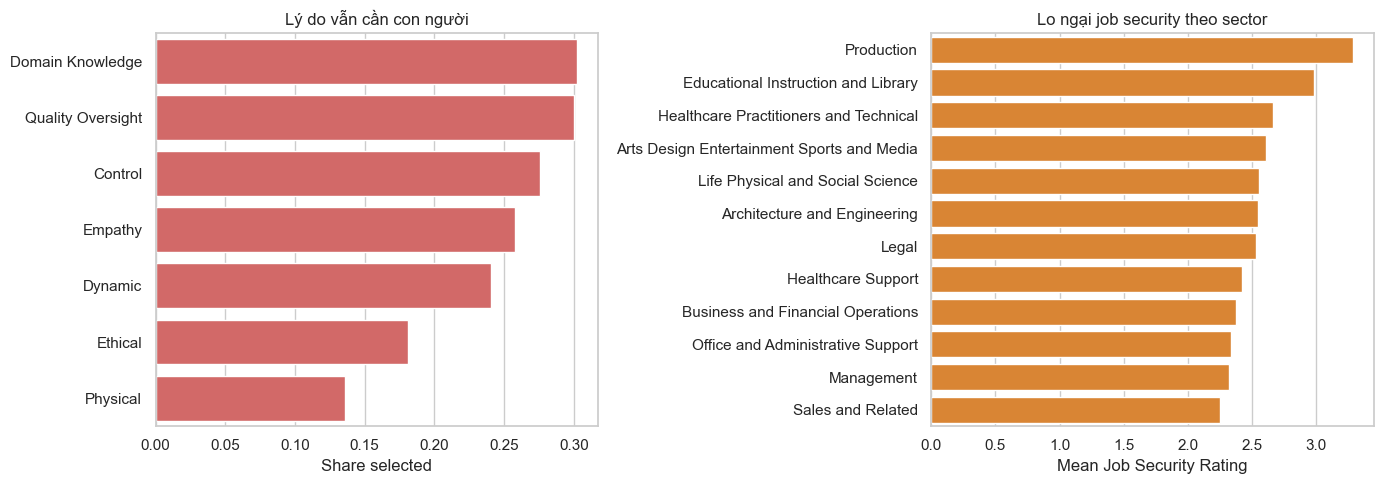

In [7]:
concern = desires.merge(meta, on=["User ID", "Occupation (O*NET-SOC Title)"], how="left")
concern["occupation_norm"] = concern["Occupation (O*NET-SOC Title)"].map(normalize_text)
concern = concern.merge(sector_lookup, on="occupation_norm", how="left")
concern["ai_suffering_attitude_score"] = concern["AI Suffering Attitude"].map(likert_map)
concern["llm_work_use_score"] = concern["LLM Use in Work"].map(llm_work_use_map)

human_agency_reason_cols = [
    "Reasons for Human Agency - Physical",
    "Reasons for Human Agency - Control",
    "Reasons for Human Agency - Domain Knowledge",
    "Reasons for Human Agency - Empathy",
    "Reasons for Human Agency - Quality Oversight",
    "Reasons for Human Agency - Dynamic",
    "Reasons for Human Agency - Ethical",
]

reason_summary = []
for col in human_agency_reason_cols:
    reason_summary.append(
        {
            "concern_reason": col.replace("Reasons for Human Agency - ", ""),
            "share_selected": concern[col].mean(),
        }
    )
reason_summary = pd.DataFrame(reason_summary).sort_values("share_selected", ascending=False)
display(reason_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=reason_summary, x="share_selected", y="concern_reason", ax=axes[0], color="#E45756")
axes[0].set_title("Lý do vẫn cần con người")
axes[0].set_xlabel("Share selected")
axes[0].set_ylabel("")

sector_concern = concern.groupby("sector", dropna=False).agg(
    responses=("Task ID", "count"),
    job_security=("Job Security Rating", "mean"),
    suffering_attitude=("ai_suffering_attitude_score", "mean"),
    human_agency=("Human Agency Scale Rating", "mean"),
).reset_index().sort_values("job_security", ascending=False)
sns.barplot(data=sector_concern.head(12), x="job_security", y="sector", ax=axes[1], color="#F58518")
axes[1].set_title("Lo ngại job security theo sector")
axes[1].set_xlabel("Mean Job Security Rating")
axes[1].set_ylabel("")
plt.tight_layout()

display(sector_concern.round(3))

# Cell 4. Suy luan bang hoi quy/uoc luong: nghe va nganh chuyen dich nhu the nao

Ta chay hoi quy o cap **worker-task response** de xem cac yeu to nao lien quan den:

1. `automation_desire`: mong muon tu dong hoa.
2. `human_agency`: nhu cau giu con nguoi trong vong kiem soat.
3. `job_security`: lo ngai an toan nghe nghiep.

Sau do dung fitted values cua mo hinh de tao **exploratory shift score** theo occupation/sector:

`exploratory_shift_score = z(predicted automation desire) + z(ai capability) - z(predicted human agency)`

Diem nay chi nen hieu la chi so kham pha de uu tien xem xet nghe/nganh co cau truc task co the doi manh. No **khong** phai xac suat mat viec, khong phai du bao nhan qua, va ranking chi dang tin hon khi nhom co du responses/users/tasks.

In [8]:
expert_for_reg = expert_task[["Task ID", "ai_capability", "physical_requirement", "uncertainty", "domain_expertise", "interpersonal"]]

reg_df = desires.merge(expert_for_reg, on="Task ID", how="left")
reg_df = reg_df.merge(meta, on=["User ID", "Occupation (O*NET-SOC Title)"], how="left")
reg_df["occupation_norm"] = reg_df["Occupation (O*NET-SOC Title)"].map(normalize_text)
reg_df = reg_df.merge(sector_lookup, on="occupation_norm", how="left")
reg_df["sector"] = reg_df["sector"].fillna("Unknown")

reg_df = reg_df.rename(
    columns={
        "User ID": "user_id",
        "Task ID": "task_id",
        "Automation Desire Rating": "automation_desire",
        "Human Agency Scale Rating": "human_agency",
        "Core Skill Rating": "core_skill",
        "Enjoyment Rating": "enjoyment",
        "Job Security Rating": "job_security",
        "Self-reported Expertise": "self_reported_expertise",
        "Occupation (O*NET-SOC Title)": "occupation",
    }
)
reg_df["llm_familiarity_score"] = reg_df["LLM Familiarity"].map(llm_familiarity_map)
reg_df["llm_work_use_score"] = reg_df["LLM Use in Work"].map(llm_work_use_map)
reg_df["ai_suffering_attitude_score"] = reg_df["AI Suffering Attitude"].map(likert_map)
reg_df["ai_positive_feeling_score"] = reg_df[
    [
        "AI Tedious Work Attitude",
        "AI Job Importance Attitude",
        "AI Daily Interest Attitude",
    ]
].apply(lambda col: col.map(likert_map)).mean(axis=1)

model_cols = [
    "automation_desire",
    "human_agency",
    "job_security",
    "ai_capability",
    "physical_requirement",
    "uncertainty",
    "domain_expertise",
    "interpersonal",
    "core_skill",
    "enjoyment",
    "llm_familiarity_score",
    "llm_work_use_score",
    "ai_positive_feeling_score",
    "ai_suffering_attitude_score",
    "sector",
    "occupation",
    "user_id",
    "task_id",
]
model_df = reg_df[model_cols].dropna().copy()
print("Regression rows:", len(model_df))
print("Users:", model_df["user_id"].nunique())
print("Tasks:", model_df["task_id"].nunique())
print("Occupations:", model_df["occupation"].nunique())

Regression rows: 5731
Users: 1361
Tasks: 844
Occupations: 104


## 4a. Kiem tra do phu du lieu va cau truc mau

Cell nay kiem tra phan du lieu nao that su di vao mo hinh. Day la buoc quan trong vi hoi quy chi dung cac dong co du worker rating, expert rating va metadata; neu do phu thap hoac sector qua nho, ranking can duoc doc than trong.

In [9]:
coverage_summary = pd.DataFrame(
    [
        {
            "unit": "task",
            "available_in_source": tasks["Task ID"].nunique(),
            "used_in_model": model_df["task_id"].nunique(),
        },
        {
            "unit": "occupation",
            "available_in_source": tasks["Occupation (O*NET-SOC Title)"].nunique(),
            "used_in_model": model_df["occupation"].nunique(),
        },
        {
            "unit": "worker/user",
            "available_in_source": meta["User ID"].nunique(),
            "used_in_model": model_df["user_id"].nunique(),
        },
    ]
)
coverage_summary["coverage_pct"] = (coverage_summary["used_in_model"] / coverage_summary["available_in_source"] * 100).round(1)
display(coverage_summary)

pre_model_missingness = (
    reg_df[model_cols]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("missing_pct_before_listwise_drop")
    .reset_index()
    .rename(columns={"index": "variable"})
    .sort_values("missing_pct_before_listwise_drop", ascending=False)
)
print("\nMissingness truoc khi dropna cho mo hinh")
display(pre_model_missingness.head(20))

print("\nSo dong lap theo user va task")
repeat_structure = pd.DataFrame(
    {
        "rows_per_user": model_df.groupby("user_id").size().describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
        "rows_per_task": model_df.groupby("task_id").size().describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]),
    }
).round(2)
display(repeat_structure)

sector_model_coverage = (
    model_df.groupby("sector", dropna=False)
    .agg(
        responses=("task_id", "count"),
        users=("user_id", "nunique"),
        tasks=("task_id", "nunique"),
        occupations=("occupation", "nunique"),
    )
    .reset_index()
    .sort_values("responses", ascending=False)
)
sector_model_coverage["low_sample_flag"] = (
    (sector_model_coverage["responses"] < 50)
    | (sector_model_coverage["users"] < 10)
    | (sector_model_coverage["occupations"] < 2)
)
print("\nDo phu theo sector trong mau hoi quy")
display(sector_model_coverage)

,unit,available_in_source,used_in_model,coverage_pct
0,task,2131,844,39.6
1,occupation,287,104,36.2
2,worker/user,1500,1361,90.7



Missingness truoc khi dropna cho mo hinh


,variable,missing_pct_before_listwise_drop
0,automation_desire,0.0
1,human_agency,0.0
16,user_id,0.0
15,occupation,0.0
14,sector,0.0
13,ai_suffering_attitude_score,0.0
12,ai_positive_feeling_score,0.0
11,llm_work_use_score,0.0
10,llm_familiarity_score,0.0
9,enjoyment,0.0



So dong lap theo user va task


,rows_per_user,rows_per_task
count,1361.00,844.00
mean,4.21,6.79
std,2.62,2.39
min,1.00,3.00
50%,3.00,7.00
75%,6.00,9.00
90%,9.00,10.00
95%,10.00,10.00
99%,10.00,10.00
max,10.00,11.00



Do phu theo sector trong mau hoi quy

,sector,responses,users,tasks,occupations,low_sample_flag
3,Computer and Mathematical,1225,298,173,20,False
2,Business and Financial Operations,1194,265,170,21,False
10,Office and Administrative Support,1039,208,152,15,False
9,Management,681,184,92,12,False
1,Arts Design Entertainment Sports and Media,547,117,82,10,False
0,Architecture and Engineering,298,85,58,8,False
12,Sales and Related,259,59,34,4,False
8,Life Physical and Social Science,205,71,39,7,False
4,Educational Instruction and Library,113,29,16,2,False
7,Legal,60,18,11,2,False


In [10]:
desire_formula = """
automation_desire ~ ai_capability + human_agency + core_skill + enjoyment + job_security
+ llm_familiarity_score + llm_work_use_score + ai_positive_feeling_score
+ physical_requirement + uncertainty + domain_expertise + interpersonal
+ C(sector)
"""

agency_formula = """
human_agency ~ ai_capability + automation_desire + core_skill + enjoyment + job_security
+ llm_familiarity_score + llm_work_use_score + ai_positive_feeling_score
+ physical_requirement + uncertainty + domain_expertise + interpersonal
+ C(sector)
"""

security_formula = """
job_security ~ ai_capability + automation_desire + human_agency + core_skill + enjoyment
+ llm_familiarity_score + llm_work_use_score + ai_suffering_attitude_score
+ physical_requirement + uncertainty + domain_expertise + interpersonal
+ C(sector)
"""


def fit_ols(formula, data, cov_type="HC3", group_col=None):
    base = smf.ols(formula, data=data)
    if group_col is None:
        return base.fit(cov_type=cov_type)
    return base.fit(cov_type="cluster", cov_kwds={"groups": data[group_col]})


model_specs = {
    "automation_desire": desire_formula,
    "human_agency": agency_formula,
    "job_security": security_formula,
}

models_hc3 = {name: fit_ols(formula, model_df, cov_type="HC3") for name, formula in model_specs.items()}
models_cluster_user = {name: fit_ols(formula, model_df, group_col="user_id") for name, formula in model_specs.items()}
models_cluster_task = {name: fit_ols(formula, model_df, group_col="task_id") for name, formula in model_specs.items()}

desire_model = models_hc3["automation_desire"]
agency_model = models_hc3["human_agency"]
security_model = models_hc3["job_security"]


def compact_model_diagnostics(model_dict):
    rows = []
    for outcome, model in model_dict.items():
        rows.append({"outcome": outcome, "nobs": int(model.nobs), "r_squared": model.rsquared, "adj_r_squared": model.rsquared_adj, "condition_number": model.condition_number})
    return pd.DataFrame(rows).round(3)


def coefficient_comparison(variable):
    rows = []
    for outcome in model_specs:
        for label, model_dict in [("HC3", models_hc3), ("cluster_user", models_cluster_user), ("cluster_task", models_cluster_task)]:
            model = model_dict[outcome]
            if variable in model.params.index:
                rows.append({"outcome": outcome, "variable": variable, "se_type": label, "coef": model.params[variable], "std_err": model.bse[variable], "p_value": model.pvalues[variable]})
    return pd.DataFrame(rows).round(4)


print("\nModel diagnostics")
display(compact_model_diagnostics(models_hc3))

print("\nSo sanh inference voi HC3 vs clustered SE")
for variable in ["ai_capability", "human_agency", "automation_desire", "job_security"]:
    table = coefficient_comparison(variable)
    if not table.empty:
        print(f"\n{variable}")
        display(table)

continuous_predictors = ["ai_capability", "human_agency", "automation_desire", "core_skill", "enjoyment", "job_security", "llm_familiarity_score", "llm_work_use_score", "ai_positive_feeling_score", "physical_requirement", "uncertainty", "domain_expertise", "interpersonal"]
X_vif = model_df[continuous_predictors].dropna().copy()
X_vif = (X_vif - X_vif.mean()) / X_vif.std(ddof=0)
X_vif.insert(0, "intercept", 1.0)
vif_table = pd.DataFrame({"variable": X_vif.columns, "vif": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]})
vif_table = vif_table[vif_table["variable"] != "intercept"].sort_values("vif", ascending=False)
print("\nKiem tra da cong tuyen VIF cho cac predictor lien tuc")
display(vif_table.round(2))

print("\nModel A: yeu to lien quan den mong muon tu dong hoa, HC3")
display(desire_model.summary().tables[1])

print("\nModel B: yeu to lien quan den nhu cau human agency/control, HC3")
display(agency_model.summary().tables[1])

print("\nModel C: yeu to lien quan den lo ngai job security, HC3")
display(security_model.summary().tables[1])


Model diagnostics


,outcome,nobs,r_squared,adj_r_squared,condition_number
0,automation_desire,5731,0.155,0.151,282.273
1,human_agency,5731,0.149,0.145,282.926
2,job_security,5731,0.250,0.247,276.298



So sanh inference voi HC3 vs clustered SE

ai_capability


,outcome,variable,se_type,coef,std_err,p_value
0,automation_desire,ai_capability,HC3,0.0087,0.0279,0.7540
1,automation_desire,ai_capability,cluster_user,0.0087,0.0335,0.7939
2,automation_desire,ai_capability,cluster_task,0.0087,0.0296,0.7672
3,human_agency,ai_capability,HC3,-0.0386,0.0252,0.1262
4,human_agency,ai_capability,cluster_user,-0.0386,0.0280,0.1686
5,human_agency,ai_capability,cluster_task,-0.0386,0.0264,0.1442
6,job_security,ai_capability,HC3,0.0144,0.0274,0.5982
7,job_security,ai_capability,cluster_user,0.0144,0.0336,0.6677
8,job_security,ai_capability,cluster_task,0.0144,0.0276,0.6015



human_agency


...

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,2.8497,0.228,12.476,0.000,2.402,3.297
C(sector)[T.Arts Design Entertainment Sports and Media],-0.4975,0.087,-5.708,0.000,-0.668,-0.327
C(sector)[T.Business and Financial Operations],-0.1026,0.077,-1.334,0.182,-0.253,0.048
C(sector)[T.Computer and Mathematical],-0.1558,0.076,-2.042,0.041,-0.305,-0.006
C(sector)[T.Educational Instruction and Library],0.0637,0.135,0.470,0.638,-0.202,0.329
C(sector)[T.Healthcare Practitioners and Technical],0.0359,0.192,0.187,0.852,-0.341,0.413
C(sector)[T.Healthcare Support],-0.1226,0.171,-0.717,0.473,-0.458,0.212
C(sector)[T.Legal],-0.1880,0.170,-1.107,0.268,-0.521,0.145
C(sector)[T.Life Physical and Social Science],0.0226,0.107,0.211,0.833,-0.187,0.232
C(sector)[T.Management],-0.1154,0.083,-1.396,0.163,-0.277,0.047



Model B: yeu to lien quan den nhu cau human agency/control, HC3


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,2.1167,0.208,10.159,0.000,1.708,2.525
C(sector)[T.Arts Design Entertainment Sports and Media],-0.0730,0.082,-0.893,0.372,-0.233,0.087
C(sector)[T.Business and Financial Operations],0.0429,0.070,0.609,0.542,-0.095,0.181
C(sector)[T.Computer and Mathematical],0.0419,0.069,0.605,0.545,-0.094,0.177
C(sector)[T.Educational Instruction and Library],-0.0858,0.129,-0.666,0.505,-0.338,0.167
C(sector)[T.Healthcare Practitioners and Technical],-0.2618,0.182,-1.437,0.151,-0.619,0.095
C(sector)[T.Healthcare Support],0.0930,0.179,0.518,0.604,-0.259,0.445
C(sector)[T.Legal],-0.1244,0.157,-0.792,0.428,-0.432,0.183
C(sector)[T.Life Physical and Social Science],0.1039,0.102,1.021,0.307,-0.095,0.303
C(sector)[T.Management],0.1473,0.074,1.996,0.046,0.003,0.292



Model C: yeu to lien quan den lo ngai job security, HC3


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-0.2318,0.219,-1.057,0.291,-0.662,0.198
C(sector)[T.Arts Design Entertainment Sports and Media],-0.0929,0.083,-1.115,0.265,-0.256,0.070
C(sector)[T.Business and Financial Operations],-0.0699,0.073,-0.952,0.341,-0.214,0.074
C(sector)[T.Computer and Mathematical],-0.1987,0.072,-2.748,0.006,-0.340,-0.057
C(sector)[T.Educational Instruction and Library],0.2882,0.128,2.247,0.025,0.037,0.540
C(sector)[T.Healthcare Practitioners and Technical],0.1872,0.175,1.071,0.284,-0.155,0.530
C(sector)[T.Healthcare Support],-0.1315,0.190,-0.694,0.488,-0.503,0.240
C(sector)[T.Legal],0.0242,0.146,0.166,0.868,-0.262,0.310
C(sector)[T.Life Physical and Social Science],-0.0088,0.108,-0.081,0.936,-0.221,0.204
C(sector)[T.Management],-0.1059,0.078,-1.352,0.176,-0.259,0.048


In [11]:
model_df["predicted_automation_desire"] = desire_model.predict(model_df)
model_df["predicted_human_agency"] = agency_model.predict(model_df)
model_df["predicted_job_security"] = security_model.predict(model_df)

model_df["score_z_predicted_automation_desire"] = zscore(model_df["predicted_automation_desire"])
model_df["score_z_ai_capability"] = zscore(model_df["ai_capability"])
model_df["score_z_negative_human_agency"] = -zscore(model_df["predicted_human_agency"])
model_df["exploratory_shift_score"] = (
    model_df["score_z_predicted_automation_desire"]
    + model_df["score_z_ai_capability"]
    + model_df["score_z_negative_human_agency"]
)

MIN_OCC_RESPONSES = 30
MIN_OCC_USERS = 10
MIN_OCC_TASKS = 5
MIN_SECTOR_RESPONSES = 50
MIN_SECTOR_USERS = 10
MIN_SECTOR_OCCUPATIONS = 2

occupation_shift = model_df.groupby(["occupation", "sector"], as_index=False).agg(
    responses=("task_id", "count"),
    users=("user_id", "nunique"),
    tasks=("task_id", "nunique"),
    predicted_automation_desire=("predicted_automation_desire", "mean"),
    ai_capability=("ai_capability", "mean"),
    predicted_human_agency=("predicted_human_agency", "mean"),
    predicted_job_security=("predicted_job_security", "mean"),
    exploratory_shift_score=("exploratory_shift_score", "mean"),
).sort_values("exploratory_shift_score", ascending=False)
occupation_shift["reliable_for_ranking"] = (
    (occupation_shift["responses"] >= MIN_OCC_RESPONSES)
    & (occupation_shift["users"] >= MIN_OCC_USERS)
    & (occupation_shift["tasks"] >= MIN_OCC_TASKS)
)

sector_shift = model_df.groupby("sector", as_index=False).agg(
    responses=("task_id", "count"),
    users=("user_id", "nunique"),
    occupations=("occupation", "nunique"),
    tasks=("task_id", "nunique"),
    predicted_automation_desire=("predicted_automation_desire", "mean"),
    ai_capability=("ai_capability", "mean"),
    predicted_human_agency=("predicted_human_agency", "mean"),
    predicted_job_security=("predicted_job_security", "mean"),
    exploratory_shift_score=("exploratory_shift_score", "mean"),
).sort_values("exploratory_shift_score", ascending=False)
sector_shift["reliable_for_ranking"] = (
    (sector_shift["responses"] >= MIN_SECTOR_RESPONSES)
    & (sector_shift["users"] >= MIN_SECTOR_USERS)
    & (sector_shift["occupations"] >= MIN_SECTOR_OCCUPATIONS)
)

reliable_occupation_shift = occupation_shift[occupation_shift["reliable_for_ranking"]].copy()
reliable_sector_shift = sector_shift[sector_shift["reliable_for_ranking"]].copy()

occupation_shift.to_csv(OUTPUT_DIR / "regression_exploratory_occupation_shift.csv", index=False, encoding="utf-8-sig")
sector_shift.to_csv(OUTPUT_DIR / "regression_exploratory_sector_shift.csv", index=False, encoding="utf-8-sig")

print("\nNghe co exploratory shift score cao nhat, da loc mau nho")
display(reliable_occupation_shift.head(20).round(3))

print("\nNganh co exploratory shift score cao nhat, da loc mau nho")
display(reliable_sector_shift.round(3))

print("\nCac occupation bi loai khoi ranking chinh vi mau nho")
display(occupation_shift[~occupation_shift["reliable_for_ranking"]].head(20).round(3))

print("\nCac sector bi gan co mau nho")
display(sector_shift[~sector_shift["reliable_for_ranking"]].round(3))


Nghe co exploratory shift score cao nhat, da loc mau nho


,occupation,sector,responses,users,tasks,predicted_automation_desire,ai_capability,predicted_human_agency,predicted_job_security,exploratory_shift_score,reliable_for_ranking
66,Payroll and Timekeeping Clerks,Office and Administrative Support,69,10,13,3.152,4.572,2.543,2.106,2.290,True
60,Medical Transcriptionists,Healthcare Support,52,11,8,3.154,4.904,2.769,2.423,2.151,True
65,Online Merchants,Business and Financial Operations,123,14,15,3.179,4.404,2.601,2.048,2.025,True
74,Proofreaders and Copy Markers,Office and Administrative Support,34,10,5,3.097,4.446,2.623,2.322,1.861,True
10,"Bookkeeping, Accounting, and Auditing Clerks",Office and Administrative Support,102,13,14,3.109,4.431,2.786,2.540,1.499,True
102,Web Developers,Computer and Mathematical,130,26,13,3.285,4.064,2.813,2.179,1.382,True
93,Tax Preparers,Business and Financial Operations,51,10,9,3.212,4.229,2.832,2.512,1.374,True
85,Search Marketing Strategists,Business and Financial Operations,107,16,14,3.225,4.084,2.796,2.342,1.321,True
91,Supply Chain Managers,Management,44,10,9,3.394,3.655,2.755,2.013,1.275,True
69,Photographers,Arts Design Entertainment Sports and Media,66,13,7,2.694,4.326,2.485,2.076,1.234,True



Nganh co exploratory shift score cao nhat, da loc mau nho


,sector,responses,users,occupations,tasks,predicted_automation_desire,ai_capability,predicted_human_agency,predicted_job_security,exploratory_shift_score,reliable_for_ranking
10,Office and Administrative Support,1039,208,15,152,2.941,3.692,2.709,2.337,0.514,True
7,Legal,60,18,2,11,2.983,3.519,2.683,2.533,0.465,True
12,Sales and Related,259,59,4,34,2.931,4.106,2.973,2.247,0.356,True
2,Business and Financial Operations,1194,265,21,170,3.055,3.646,2.866,2.373,0.336,True
3,Computer and Mathematical,1225,298,20,173,3.119,3.413,2.892,2.234,0.145,True
9,Management,681,184,12,92,3.065,3.400,2.981,2.323,-0.179,True
8,Life Physical and Social Science,205,71,7,39,3.205,3.116,3.005,2.551,-0.268,True
4,Educational Instruction and Library,113,29,2,16,3.062,3.167,2.956,2.982,-0.387,True
0,Architecture and Engineering,298,85,8,58,3.114,2.965,2.953,2.544,-0.500,True
1,Arts Design Entertainment Sports and Media,547,117,10,82,2.516,3.064,2.985,2.609,-1.662,True



Cac occupation bi loai khoi ranking chinh vi mau nho


,occupation,sector,responses,users,tasks,predicted_automation_desire,ai_capability,predicted_human_agency,predicted_job_security,exploratory_shift_score,reliable_for_ranking
17,Compliance Officers,Business and Financial Operations,20,8,3,3.273,3.967,2.765,2.320,1.359,False
34,"Eligibility Interviewers, Government Programs",Office and Administrative Support,18,9,4,3.012,3.852,2.580,2.125,1.126,False
54,Management Analysts,Business and Financial Operations,20,7,4,3.080,3.900,2.774,2.377,0.877,False
30,Data Entry Keyers,Office and Administrative Support,37,9,6,3.036,3.757,2.672,2.382,0.859,False
49,Lawyers,Legal,19,8,3,2.997,3.816,2.692,2.786,0.802,False
88,Social Science Research Assistants,Life Physical and Social Science,27,10,5,3.214,3.556,2.810,2.220,0.678,False
35,"Energy Engineers, Except Wind and Solar",Architecture and Engineering,27,9,6,3.376,3.074,2.783,2.449,0.530,False
7,Biofuels Production Managers,Management,24,8,6,3.213,3.694,2.967,2.324,0.476,False
76,Public Safety Telecommunicators,Office and Administrative Support,22,8,5,3.148,3.273,2.705,2.743,0.472,False
38,Financial Quantitative Analysts,Business and Financial Operations,30,15,3,3.145,3.500,2.827,2.485,0.441,False



Cac sector bi gan co mau nho


,sector,responses,users,occupations,tasks,predicted_automation_desire,ai_capability,predicted_human_agency,predicted_job_security,exploratory_shift_score,reliable_for_ranking
6,Healthcare Support,52,11,1,8,3.154,4.904,2.769,2.423,2.151,False
5,Healthcare Practitioners and Technical,51,11,1,7,3.059,2.549,2.863,2.667,-0.870,False
11,Production,7,5,1,2,3.000,2.429,3.714,3.286,-3.050,False


## 4b. Sensitivity analysis cho exploratory shift score

Cell nay kiem tra ranking co on dinh khi bo tung thanh phan cua score, va so sanh response-level score voi task-level aggregate. Neu tuong quan rank thap, ranking nen duoc xem la tin hieu rat mong manh.

In [12]:
score_specs = {
    "base": ["score_z_predicted_automation_desire", "score_z_ai_capability", "score_z_negative_human_agency"],
    "drop_predicted_automation_desire": ["score_z_ai_capability", "score_z_negative_human_agency"],
    "drop_ai_capability": ["score_z_predicted_automation_desire", "score_z_negative_human_agency"],
    "drop_negative_human_agency": ["score_z_predicted_automation_desire", "score_z_ai_capability"],
}

variant_frames = []
for variant, columns in score_specs.items():
    temp = model_df.copy()
    temp[f"score_{variant}"] = temp[columns].sum(axis=1)
    occ_variant = (
        temp.groupby(["occupation", "sector"], as_index=False)
        .agg(responses=("task_id", "count"), users=("user_id", "nunique"), tasks=("task_id", "nunique"), score=(f"score_{variant}", "mean"))
    )
    occ_variant["variant"] = variant
    variant_frames.append(occ_variant)

variant_scores = pd.concat(variant_frames, ignore_index=True)
variant_scores["reliable_for_ranking"] = (
    (variant_scores["responses"] >= MIN_OCC_RESPONSES)
    & (variant_scores["users"] >= MIN_OCC_USERS)
    & (variant_scores["tasks"] >= MIN_OCC_TASKS)
)
variant_scores = variant_scores[variant_scores["reliable_for_ranking"]]

variant_wide = variant_scores.pivot(index="occupation", columns="variant", values="score")
rank_correlations = (
    variant_wide.rank(ascending=False)
    .corr(method="spearman")
    .loc[["base"], [col for col in variant_wide.columns if col != "base"]]
    .T
    .rename(columns={"base": "spearman_rank_corr_with_base"})
    .reset_index()
)
print("\nRank correlation khi bo tung thanh phan score")
display(rank_correlations.round(3))

top_base = (
    variant_scores[variant_scores["variant"] == "base"]
    .sort_values("score", ascending=False)
    .head(15)[["occupation", "sector", "responses", "users", "tasks", "score"]]
)
print("\nTop occupation theo base score trong mau reliable")
display(top_base.round(3))

task_level = (
    model_df.groupby(["task_id", "occupation", "sector"], as_index=False)
    .agg(
        responses=("user_id", "count"),
        users=("user_id", "nunique"),
        predicted_automation_desire=("predicted_automation_desire", "mean"),
        ai_capability=("ai_capability", "mean"),
        predicted_human_agency=("predicted_human_agency", "mean"),
    )
)
task_level["task_level_exploratory_shift_score"] = (
    zscore(task_level["predicted_automation_desire"])
    + zscore(task_level["ai_capability"])
    - zscore(task_level["predicted_human_agency"])
)
task_level_occupation = (
    task_level.groupby(["occupation", "sector"], as_index=False)
    .agg(tasks=("task_id", "nunique"), responses=("responses", "sum"), users=("users", "sum"), task_level_exploratory_shift_score=("task_level_exploratory_shift_score", "mean"))
)
task_level_occupation["reliable_for_ranking"] = (
    (task_level_occupation["responses"] >= MIN_OCC_RESPONSES)
    & (task_level_occupation["tasks"] >= MIN_OCC_TASKS)
)

response_vs_task = reliable_occupation_shift[["occupation", "exploratory_shift_score"]].merge(
    task_level_occupation[task_level_occupation["reliable_for_ranking"]][["occupation", "task_level_exploratory_shift_score"]],
    on="occupation",
    how="inner",
)
rank_corr_response_task = response_vs_task[["exploratory_shift_score", "task_level_exploratory_shift_score"]].rank(ascending=False).corr(method="spearman").iloc[0, 1]
print(f"\nSpearman rank correlation response-level vs task-level: {rank_corr_response_task:.3f}")
display(response_vs_task.sort_values("exploratory_shift_score", ascending=False).head(20).round(3))


Rank correlation khi bo tung thanh phan score


variant,variant,spearman_rank_corr_with_base
0,drop_ai_capability,0.804
1,drop_negative_human_agency,0.946
2,drop_predicted_automation_desire,0.934



Top occupation theo base score trong mau reliable


,occupation,sector,responses,users,tasks,score
66,Payroll and Timekeeping Clerks,Office and Administrative Support,69,10,13,2.290
60,Medical Transcriptionists,Healthcare Support,52,11,8,2.151
65,Online Merchants,Business and Financial Operations,123,14,15,2.025
74,Proofreaders and Copy Markers,Office and Administrative Support,34,10,5,1.861
10,"Bookkeeping, Accounting, and Auditing Clerks",Office and Administrative Support,102,13,14,1.499
102,Web Developers,Computer and Mathematical,130,26,13,1.382
93,Tax Preparers,Business and Financial Operations,51,10,9,1.374
85,Search Marketing Strategists,Business and Financial Operations,107,16,14,1.321
91,Supply Chain Managers,Management,44,10,9,1.275
69,Photographers,Arts Design Entertainment Sports and Media,66,13,7,1.234



Spearman rank correlation response-level vs task-level: 0.974


,occupation,exploratory_shift_score,task_level_exploratory_shift_score
0,Payroll and Timekeeping Clerks,2.290,3.147
1,Medical Transcriptionists,2.151,2.536
2,Online Merchants,2.025,2.498
3,Proofreaders and Copy Markers,1.861,2.342
4,"Bookkeeping, Accounting, and Auditing Clerks",1.499,1.980
5,Web Developers,1.382,1.909
6,Tax Preparers,1.374,1.818
7,Search Marketing Strategists,1.321,1.697
8,Supply Chain Managers,1.275,2.064
9,Photographers,1.234,1.480


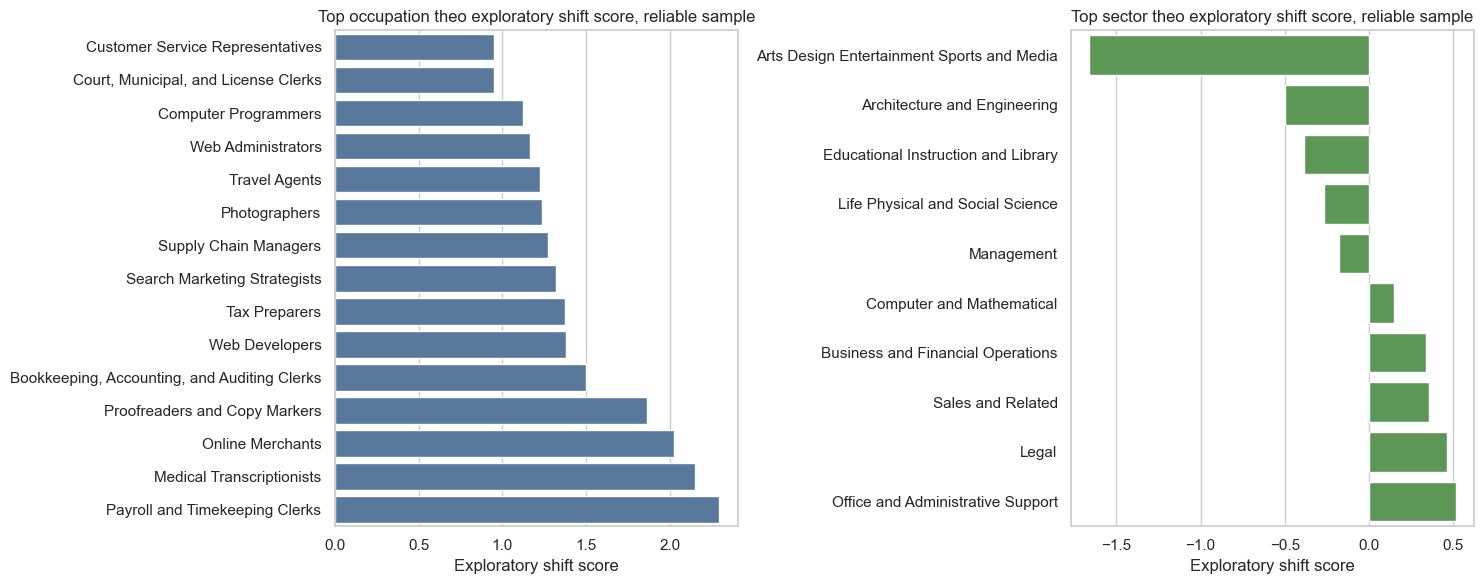

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_occ = reliable_occupation_shift.head(15).iloc[::-1]
sns.barplot(data=top_occ, x="exploratory_shift_score", y="occupation", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top occupation theo exploratory shift score, reliable sample")
axes[0].set_xlabel("Exploratory shift score")
axes[0].set_ylabel("")

top_sector = reliable_sector_shift.head(12).iloc[::-1]
sns.barplot(data=top_sector, x="exploratory_shift_score", y="sector", ax=axes[1], color="#54A24B")
axes[1].set_title("Top sector theo exploratory shift score, reliable sample")
axes[1].set_xlabel("Exploratory shift score")
axes[1].set_ylabel("")
plt.tight_layout()

## Dien giai ket qua hoi quy sau khi bo sung kiem tra chat luong

Khi doc bang hoi quy:

- Coefficient duong: bien do lien quan den muc rating cao hon, giu cac bien khac khong doi.
- Coefficient am: bien do lien quan den muc rating thap hon.
- P-value nho chi noi rang lien he thong ke ro trong mau du lieu nay, chua chung minh nhan qua.
- Voi du lieu response-level co nhieu dong lap theo cung user/task, uu tien doc them bang clustered standard errors theo `user_id` va `task_id`, khong chi HC3.
- `exploratory_shift_score` la chi so kham pha de xep hang nghe/nganh can xem ky hon. No khong nen duoc hieu la xac suat mat viec hoac du bao chac chan.
- Ranking chinh da loc occupation/sector co mau qua nho, nhung van can doc cung so `responses`, `users`, `tasks` va sensitivity analysis.
- Neu rank correlation trong sensitivity thap, insight nen duoc trinh bay nhu tin hieu mong manh can kiem chung them.

Huong dien giai tot nhat: AI co the lam thay phan nao, con nguoi chuyen sang kiem soat/danh gia/phoi hop phan nao, va nhom nghe/nganh nao dang uu tien nghien cuu sau hoac thiet ke reskilling truoc.